## Individual Game Logs by Pitch

Baseball Savant's Statcast search provides pitch-level records. The next cells request Statcast data for each batter on a given team in a given season for each pitch they see.

CSV Documentation: https://baseballsavant.mlb.com/csv-docs

In [32]:
from io import StringIO
from pathlib import Path
import pandas as pd
import numpy as np
import requests
from calendar import monthrange
from datetime import date

STATCAST_URL = 'https://baseballsavant.mlb.com/statcast_search/csv'
SEASON = 2026
TEAM = 'NYY' #Team Abbreviation (ex: 'NYY' for Yankees)

CURRENT_DIR = Path.cwd()

DATA_DIR = CURRENT_DIR.parent / 'data'
DATA_DIR.mkdir(exist_ok=True)

RAW_DATA_DIR = DATA_DIR / 'raw'
RAW_DATA_DIR.mkdir(exist_ok=True)

PROCESSED_DATA_DIR = DATA_DIR / 'processed'
PROCESSED_DATA_DIR.mkdir(exist_ok=True)

RAW_DATA_FILE = RAW_DATA_DIR / f'{SEASON}_{TEAM or "all"}_complete_pitch_log.csv'
PA_RESULT_FILE = PROCESSED_DATA_DIR / f'{SEASON}_{TEAM or "all"}_pa_results.csv'
LINE_SCORE_FILE = PROCESSED_DATA_DIR / f'{SEASON}_{TEAM or "all"}_line_scores.csv'

In [33]:
def get_statcast_month(season, month, team=''):
    start_date = date(season, month, 1)
    end_date = date(season, month, monthrange(season, month)[1])
    params = {
        'all': 'true',
        'type': 'batter',
        'player_type': 'batter',
        'game_type': 'r',
        'hfSea': f'{season}|',
        'hfTeam': f'{team}|' if team else '',
        'game_date_gt': start_date.isoformat(),
        'game_date_lt': end_date.isoformat(),
    }
    response = requests.get(STATCAST_URL, params=params, timeout=120)
    response.raise_for_status()
    if not response.text.strip():
        return pd.DataFrame()
    return pd.read_csv(StringIO(response.text), low_memory=False)

# Truncates dataset to all pitch/swing stats for a given plate appearance where the result was an event (hit, walk, etc.)
def build_plate_appearance_logs(statcast_df, season, team):
    
    hit_events = {'single', 'double', 'triple', 'home_run'}
    non_ab_events = {
        'walk', 'intent_walk', 'hit_by_pitch', 'sac_bunt',
        'sac_fly', 'sac_fly_double_play', 'catcher_interf',
    }
    non_pa_events = {'truncated_pa'} #Ex: runner caught stealing and inning ends (not an official PA for batter)
    non_rbi_events = {'field_error', 'sac_fly_double_play', 'grounded_into_double_play', 'double_play', 'triple_play', 'strikeout_double_play'}

    pa_results = statcast_df[statcast_df['events'].notna()].copy()

    pa_results['batter'] = pd.to_numeric(pa_results['batter'], errors='coerce').astype('Int64')
    pa_results['pa'] = (~pa_results['events'].isin(non_pa_events)).astype(int)
    pa_results['ab'] = (~pa_results['events'].isin(non_ab_events)).astype(int)
    pa_results['h'] = pa_results['events'].isin(hit_events).astype(int)
    pa_results['singles'] = (pa_results['events'] == 'single').astype(int)
    pa_results['doubles'] = (pa_results['events'] == 'double').astype(int)
    pa_results['triples'] = (pa_results['events'] == 'triple').astype(int)
    pa_results['hr'] = (pa_results['events'] == 'home_run').astype(int)

    score_change = (
        pd.to_numeric(pa_results['post_bat_score'], errors='coerce')
        - pd.to_numeric(pa_results['bat_score'], errors='coerce')
    )

    pa_results['rbi'] = score_change.where(~pa_results['events'].isin(non_rbi_events), 0)
    pa_results['bb'] = pa_results['events'].isin({'walk', 'intent_walk'}).astype(int)
    pa_results['hbp'] = (pa_results['events'] == 'hit_by_pitch').astype(int)
    pa_results['so'] = pa_results['events'].isin({'strikeout', 'strikeout_double_play'}).astype(int)
    pa_results['sb'] = pa_results['events'].str.startswith('stolen_base', na=False).astype(int)
    pa_results['cs'] = pa_results['events'].str.startswith('caught_stealing', na=False).astype(int)
    pa_results['tb'] = (
        pa_results['singles']
        + (2 * pa_results['doubles'])
        + (3 * pa_results['triples'])
        + (4 * pa_results['hr'])
    )

    return pa_results

# Groups plate appearances by game and player, summing the relevant stats to create a game log for each player in each game
def build_game_logs(pa_results, season, team):
    if pa_results.empty:
        return pd.DataFrame()

    pa_results = pa_results.copy()
    
    pa_results['opposing_team'] = np.where(
        pa_results['home_team'] == team,
        pa_results['away_team'],
        pa_results['home_team']
    )

    group_columns = ['game_pk', 'game_date', 'batter', 'player_name', 'opposing_team']
    game_logs = pa_results.groupby(group_columns, as_index=False)[[
        'pa', 'ab', 'h', 'singles', 'doubles', 'triples', 'hr',
        'bb', 'hbp', 'so', 'sb', 'cs', 'rbi', 'tb',
    ]].sum()

    game_logs = game_logs.rename(columns={'batter': 'player_id'})
    game_logs['season'] = season
    
    #game_logs.head(50)

    return game_logs

def pa_statcast_data(statcast_df, season, team):

    desc_df = statcast_df[statcast_df['description'].notna()].copy()
    
    pitch_result_events = desc_df['description'].unique()
    pitch_result_events = pd.Series(pitch_result_events).to_dict()

    print(f'Pitch Result Events: {pitch_result_events}')

    desc_df['num_pitches'] = desc_df.groupby(['game_pk', 'at_bat_number'])['pitch_number'].transform('count')
    desc_df['swings'] = desc_df['description'].isin({'hit_into_play', 'swinging_strike',
                                                     'foul', 'foul_tip', 'swinging_strike_blocked',
                                                     'foul_bunt', 'missed_bunt', 'bunt_foul_tip'}).astype(int)
    
    pa_statcast_df = desc_df[desc_df['events'].notna()].copy()

    return pa_statcast_df

In [34]:
# Run data retrieval for each month of the season into a single dataframe
monthly_statcast = []
for month in range(1, 13):
    month_df = get_statcast_month(SEASON, month, TEAM)
    if not month_df.empty:
        monthly_statcast.append(month_df)
    print(f'Processed month {month}/12; pitch rows: {sum(len(df) for df in monthly_statcast)}')

statcast_df = pd.concat(monthly_statcast, ignore_index=True)
statcast_df = statcast_df.dropna(how='all', axis=1) # Drop empty columns
statcast_df = statcast_df[statcast_df['game_type'] == 'R']  # Filter for regular season games only
statcast_df.to_csv(RAW_DATA_FILE, index=False, encoding='utf-8') #utf-8-sig for excel

Processed month 1/12; pitch rows: 0
Processed month 2/12; pitch rows: 1440
Processed month 3/12; pitch rows: 5367
Processed month 4/12; pitch rows: 9361
Processed month 5/12; pitch rows: 13636
Processed month 6/12; pitch rows: 17394
Processed month 7/12; pitch rows: 21065
Processed month 8/12; pitch rows: 25183
Processed month 9/12; pitch rows: 27583
Processed month 10/12; pitch rows: 27583
Processed month 11/12; pitch rows: 27583
Processed month 12/12; pitch rows: 27583


In [35]:
# Process and break up entire pitch log dataset into plate appearance and individual game line score datasets
if not statcast_df.empty:
    pa_df = build_plate_appearance_logs(statcast_df, SEASON, TEAM)
    pa_df.to_csv(PA_RESULT_FILE, index=False, encoding='utf-8')
    print(f'Wrote {len(pa_df)} plate appearance result rows to {PA_RESULT_FILE}')
    if not pa_df.empty:
        line_score_df = build_game_logs(pa_df, SEASON, TEAM)
        line_score_df.to_csv(LINE_SCORE_FILE, index=False, encoding='utf-8')
        print(f'Wrote {len(line_score_df)} player-game rows to {LINE_SCORE_FILE}')
else:
    statcast_df = pd.DataFrame()
    pa_df = pd.DataFrame()
    print('No Statcast game-log data was found.')

Wrote 5762 plate appearance result rows to /mnt/c/users/noahj/documents/2026/game-score-model/data/processed/2026_NYY_pa_results.csv
Wrote 1568 player-game rows to /mnt/c/users/noahj/documents/2026/game-score-model/data/processed/2026_NYY_line_scores.csv


In [36]:
pa_statcast_data(statcast_df, SEASON, TEAM)

Pitch Result Events: {0: 'hit_into_play', 1: 'ball', 2: 'called_strike', 3: 'swinging_strike', 4: 'blocked_ball', 5: 'foul', 6: 'foul_tip', 7: 'swinging_strike_blocked', 8: 'hit_by_pitch', 9: 'foul_bunt', 10: 'missed_bunt', 11: 'automatic_ball', 12: 'automatic_strike', 13: 'pitchout', 14: 'bunt_foul_tip'}


,pitch_type,game_date,release_speed,release_pos_x,release_pos_z,player_name,batter,pitcher,events,description,...,api_break_x_arm,api_break_x_batter_in,arm_angle,attack_angle,attack_direction,swing_path_tilt,intercept_ball_minus_batter_pos_x_inches,intercept_ball_minus_batter_pos_y_inches,num_pitches,swings
1440,FS,2026-03-31,79.9,-0.94,6.07,"Stanton, Giancarlo",519317,669302,double,hit_into_play,...,0.24,0.24,44.1,NaN,NaN,NaN,NaN,NaN,4,1
1444,SL,2026-03-31,87.0,-0.87,6.05,"Rice, Ben",700250,669302,walk,ball,...,-0.09,0.09,47.6,NaN,NaN,NaN,NaN,NaN,5,0
1449,FF,2026-03-31,95.4,-0.80,5.94,"Bellinger, Cody",641355,669302,single,hit_into_play,...,0.42,-0.42,47.5,4.687902,6.312492,27.183682,27.903890,23.824855,4,1
1453,FS,2026-03-31,79.6,-0.93,6.04,"Judge, Aaron",592450,669302,strikeout,swinging_strike,...,-0.38,-0.38,43.1,20.064991,-22.100982,32.430699,55.690185,44.713793,7,1
1460,FC,2026-03-31,91.0,-0.95,6.08,"Grisham, Trent",663757,669302,double,hit_into_play,...,-0.15,0.15,44.4,34.413685,-2.847092,22.355928,33.438559,28.650344,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
27565,SL,2026-09-01,79.0,3.22,4.54,"Bellinger, Cody",641355,671111,single,hit_into_play,...,-0.59,-0.59,9.8,13.818501,-4.272739,28.645606,30.807895,34.056548,4,1
27570,FF,2026-09-01,96.6,1.12,6.15,"Jones, Spencer",682987,696519,walk,ball,...,0.41,0.41,50.2,NaN,NaN,NaN,NaN,NaN,4,0
27572,SI,2026-09-01,92.3,2.06,5.55,"Wells, Austin",669224,642048,single,hit_into_play,...,1.34,1.34,24.9,13.042659,-3.992048,39.040654,35.031201,31.551216,3,1
27574,FF,2026-09-01,96.7,-2.83,5.79,"Rice, Ben",700250,680570,strikeout,swinging_strike,...,1.06,-1.06,36.0,-0.468831,19.299712,37.256927,43.350507,10.104178,3,1


## First Model

Predict line score based on a few factors like previous games' line scores & team matchup

In [37]:
line_score_df.describe(include='all')

,game_pk,game_date,player_id,player_name,opposing_team,pa,ab,h,singles,doubles,triples,hr,bb,hbp,so,sb,cs,rbi,tb,season
count,1568.000000,1568,1568.0,1568,1568,1568.000000,1568.000000,1568.000000,1568.000000,1568.000000,1568.00000,1568.000000,1568.000000,1568.000000,1568.000000,1568.0,1568.0,1568.000000,1568.000000,1568.0
unique,NaN,151,<NA>,22,29,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,2026-08-29,<NA>,"Rice, Ben",BOS,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,23,<NA>,147,142,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,823707.961735,NaN,653588.370536,NaN,NaN,3.665816,3.264031,0.764031,0.478954,0.137755,0.01148,0.135842,0.352041,0.023597,0.897321,0.0,0.0,0.436862,1.332270,2026.0
std,586.606117,NaN,54774.537996,NaN,NaN,1.158991,1.180757,0.836580,0.674688,0.371483,0.10656,0.364389,0.623755,0.151838,0.872346,0.0,0.0,0.850597,1.767589,0.0
min,822708.000000,NaN,502671.0,NaN,NaN,1.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.000000,0.000000,2026.0
25%,823501.750000,NaN,641857.0,NaN,NaN,3.000000,3.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.000000,0.000000,2026.0
50%,823540.000000,NaN,665862.0,NaN,NaN,4.000000,4.000000,1.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,1.000000,0.0,0.0,0.000000,1.000000,2026.0
75%,823983.250000,NaN,680474.0,NaN,NaN,4.000000,4.000000,1.000000,1.000000,0.000000,0.00000,0.000000,1.000000,0.000000,1.000000,0.0,0.0,1.000000,2.000000,2026.0


In [38]:
line_score_df.corr(numeric_only=True)

,game_pk,player_id,pa,ab,h,singles,doubles,triples,hr,bb,hbp,so,sb,cs,rbi,tb,season
game_pk,1.000000,-0.012456,0.035115,0.028523,0.002140,0.030383,-0.033478,0.015852,-0.021848,0.019342,-0.006159,-0.002063,NaN,NaN,0.015191,-0.017623,NaN
player_id,-0.012456,1.000000,0.036417,0.021125,-0.007676,0.002618,-0.014996,0.026749,-0.015005,0.021033,0.022524,0.012164,NaN,NaN,-0.017445,-0.012839,NaN
pa,0.035115,0.036417,1.000000,0.839086,0.395138,0.295408,0.151459,0.077587,0.183113,0.256411,0.004949,0.216623,NaN,NaN,0.247874,0.341447,NaN
ab,0.028523,0.021125,0.839086,1.000000,0.410039,0.305777,0.157084,0.051975,0.199881,-0.266653,-0.102404,0.297083,NaN,NaN,0.224384,0.356964,NaN
h,0.002140,-0.007676,0.395138,0.410039,1.000000,0.778113,0.383933,0.109151,0.431793,-0.030262,-0.026472,-0.163514,NaN,NaN,0.521618,0.834181,NaN
singles,0.030383,0.002618,0.295408,0.305777,0.778113,1.000000,-0.067357,-0.005514,0.005147,-0.020293,-0.041870,-0.131076,NaN,NaN,0.165595,0.356635,NaN
doubles,-0.033478,-0.014996,0.151459,0.157084,0.383933,-0.067357,1.000000,-0.007732,-0.011040,-0.019391,0.055473,-0.076450,NaN,NaN,0.132563,0.384115,NaN
triples,0.015852,0.026749,0.077587,0.051975,0.109151,-0.005514,-0.007732,1.000000,-0.023751,0.044773,-0.016753,-0.042233,NaN,NaN,0.155855,0.155917,NaN
hr,-0.021848,-0.015005,0.183113,0.199881,0.431793,0.005147,-0.011040,-0.023751,1.000000,-0.025226,-0.034904,-0.042419,NaN,NaN,0.710224,0.817631,NaN
bb,0.019342,0.021033,0.256411,-0.266653,-0.030262,-0.020293,-0.019391,0.044773,-0.025226,1.000000,-0.040600,-0.135250,NaN,NaN,-0.004989,-0.028601,NaN


## Potentially Important Features for a More Complex Model:

1. Pitch Type - need to enumerate
2. Game Date ?
3. pfx_x and pfx_z (horizontal and vertical movement, respectively, of pitch from release to crossing plate, from catcher's perspective)
4. Zone:

    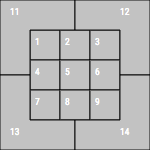

5. Event - need to enumerate
6. Stand (batter L/R), p_throws (pitcher L/R)
7. Type (ball/strike/in play) - enumerate
8. Hit location (pos. of fielder)
9. bb_type (batted ball type - line drive, fly ball, etc) - enumerate
10. Count (balls / strikes)
11. Runners on
12. Current # of outs
13. Inning
14. sz_top / sz_bot (top/bottom of batter's strike zone}
15. hit_distance
16. launch_speed
17. effective_speed (derived speed based on pitcher's extension)
18. release_pos_y (release position of pitch measured in feet from the catcher's perspective)
19. release_spin (spin rate)
20. release_extension
21. arm_angle
22. score before/after event
23. bat_speed
24. swing_length
25. miss_distance
